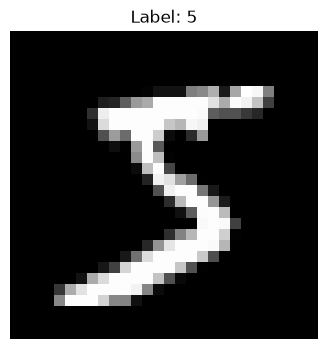

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = r'C:\Users\PC-LAB1\Desktop\New folder\day 5\mnist\archive\mnist_train.csv'  # Replace with your actual file path
df = pd.read_csv(file_path)

# 1. Extract the label from column 0, and the 784 pixels from column 1 onwards
label = df.iloc[0, 0]
pixels = df.iloc[0, 1:].values.astype(np.float32)

# 2. Reshape 784 values into a 28x28 matrix
img = pixels.reshape((28, 28))

# 3. Display the image with its label
plt.figure(figsize=(4, 4))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title(f"Label: {label}")
plt.show()

In [2]:
!pip install pandas


Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for pandas from https://files.pythonhosted.org/packages/bd/2a/14b3b17cd75cef4a1ee1af4234eb41cc1afe4103b98c2d80e8916abfd42b/pandas-3.0.6-cp312-cp312-win_amd64.whl.metadata
  Obtaining dependency information for tzdata from https://files.pythonhosted.org/packages/f9/bc/8737e8d54cf51106118039b83f485a4783112fab49ea9d044b234978a46e/tzdata-2026.4-py2.py3-none-any.whl.metadata
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   ---------------------------------------- 0.1/9.7 MB 991.0 kB/s eta 0:00:10
    --------------------------------------- 0.1/9.7 MB 1.1 MB/s eta 0:00:09
    --------------------------------------- 0.2/9.7 MB 919.0 kB/s eta 0:00:11
    --------------------------------------- 0.2/9.7 MB 1.0 MB/s eta 0:00:10
   - -------------------------------------- 0.3/9.7 MB 1.0 MB/s eta 


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Dataset loaded successfully
Dataset shape: (60000, 785)
   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      5    0    0    0    0    0    0    0    0    0  ...      0      0   
1      0    0    0    0    0    0    0    0    0    0  ...      0      0   
2      4    0    0    0    0    0    0    0    0    0  ...      0      0   
3      1    0    0    0    0    0    0    0    0    0  ...      0      0   
4      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0      0      0  
2      0      0      0      0      0      0      0      0  
3      0      0      0      0      0      0      0      0  
4      0      0      0      0      0      0      0      0  

[5 rows x 785 columns]

Number of features: 784
Number of classes: 10
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int6

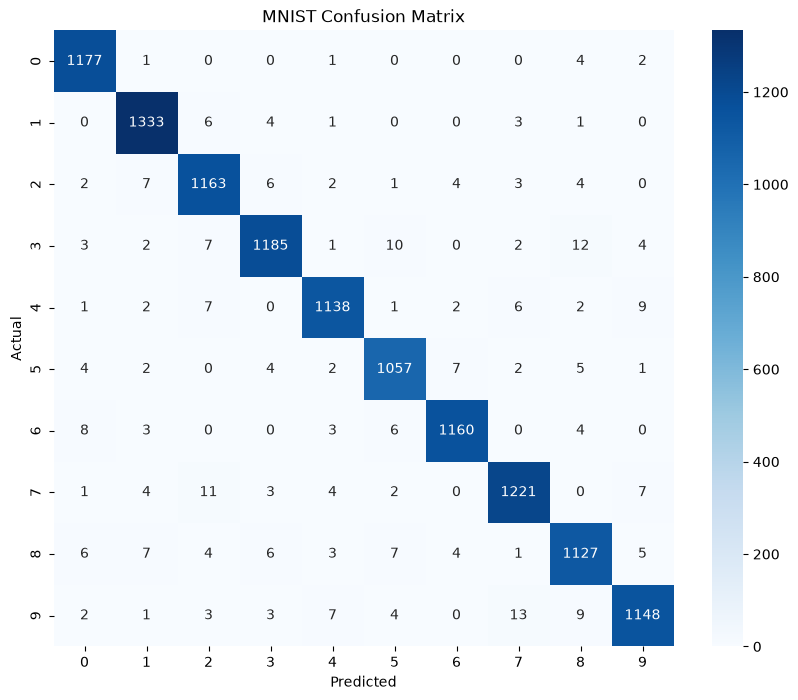


Model saved:
mnist_ann_model.pkl
Scaler saved:
mnist_scaler.pkl


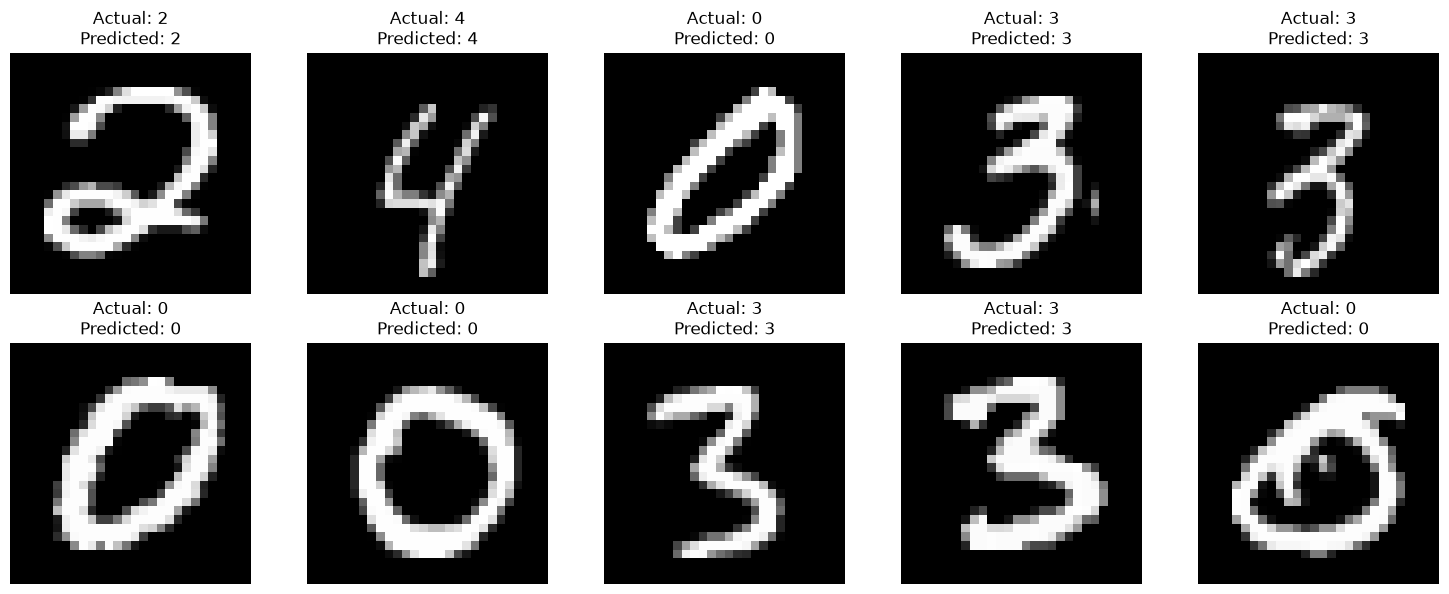


CSV saved successfully:
mnist_test_results.csv


In [16]:
import pandas as pd
import numpy as np
import random
import joblib
import csv

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns


# ==========================================
# 1 - مسار Dataset
# ==========================================

dataset_path = r"C:\Users\PC-LAB1\Desktop\New folder\day 5\mnist\archive\mnist_train.csv"


# ==========================================
# 2 - قراءة Dataset
# ==========================================

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully")

print("Dataset shape:", df.shape)

print(df.head())


# ==========================================
# 3 - فصل Label عن Features
# ==========================================

y = df["label"]

X = df.drop("label", axis=1)


print("\nNumber of features:", X.shape[1])

print("Number of classes:", y.nunique())

print("Classes:", sorted(y.unique()))


# ==========================================
# 4 - تحويل Pixel Values
# ==========================================

X = X.values
y = y.values

# تحويل القيم من 0-255 إلى 0-1
X = X / 255.0


# ==========================================
# 5 - تقسيم البيانات
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", len(X_train))

print("Testing samples:", len(X_test))


# ==========================================
# 6 - StandardScaler
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)


print("\nScaling completed")


# ==========================================
# 7 - ANN Model
# ==========================================

model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    max_iter=50,
    random_state=42,
    verbose=True
)


print("\n======================================")
print("Training ANN")
print("======================================")


model.fit(
    X_train_scaled,
    y_train
)


print("\nTraining completed")


# ==========================================
# 8 - Prediction
# ==========================================

y_pred = model.predict(X_test_scaled)


# ==========================================
# 9 - Accuracy
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)


print("\n======================================")
print("MNIST ANN RESULTS")
print("======================================")

print(
    f"Accuracy: {accuracy * 100:.2f}%"
)


# ==========================================
# 10 - Classification Report
# ==========================================

print("\n======================================")
print("Classification Report")
print("======================================")

print(
    classification_report(
        y_test,
        y_pred
    )
)


# ==========================================
# 11 - Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("MNIST Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


# ==========================================
# 12 - Save Model
# ==========================================

joblib.dump(
    model,
    "mnist_ann_model.pkl"
)

joblib.dump(
    scaler,
    "mnist_scaler.pkl"
)


print("\nModel saved:")
print("mnist_ann_model.pkl")

print("Scaler saved:")
print("mnist_scaler.pkl")


# ==========================================
# 13 - اختبار 10 صور عشوائية
# ==========================================

random.seed(42)

random_indices = random.sample(
    range(len(X_test)),
    10
)


plt.figure(figsize=(15, 6))


for i, index in enumerate(random_indices):

    image = X_test[index].reshape(28, 28)

    actual = y_test[index]

    prediction = y_pred[index]

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        image,
        cmap="gray"
    )

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {prediction}"
    )

    plt.axis("off")


plt.tight_layout()

plt.show()


# ==========================================
# 14 - حفظ نتائج الاختبار في CSV
# ==========================================

csv_path = "mnist_test_results.csv"


with open(
    csv_path,
    "w",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.writer(file)

    writer.writerow([
        "Actual",
        "Predicted"
    ])

    for actual, prediction in zip(
        y_test,
        y_pred
    ):

        writer.writerow([
            actual,
            prediction
        ])


print("\nCSV saved successfully:")

print(csv_path)

In [5]:
!pip install seaborn


Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   - -------------------------------------- 10.2/294.9 kB ? eta -:--:--
   -------- ------------------------------ 61.4/294.9 kB 825.8 kB/s eta 0:00:01
   ------------ -------------------------- 92.2/294.9 kB 880.9 kB/s eta 0:00:01
   --------------------------- ------------ 204.8/294.9 kB 1.2 MB/s eta 0:00:01
   -------------------------------------- - 286.7/294.9 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 1.2 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Model loaded successfully
Scaler loaded successfully

Test Dataset loaded successfully
Test shape: (10000, 785)
Scaling completed

MNIST TEST RESULTS
Test Accuracy: 97.59%

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.97      0.97      1032
           3       0.97      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.98      0.98      0.98       892
           6       0.98      0.98      0.98       958
           7       0.98      0.97      0.97      1028
           8       0.97      0.96      0.96       974
           9       0.97      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



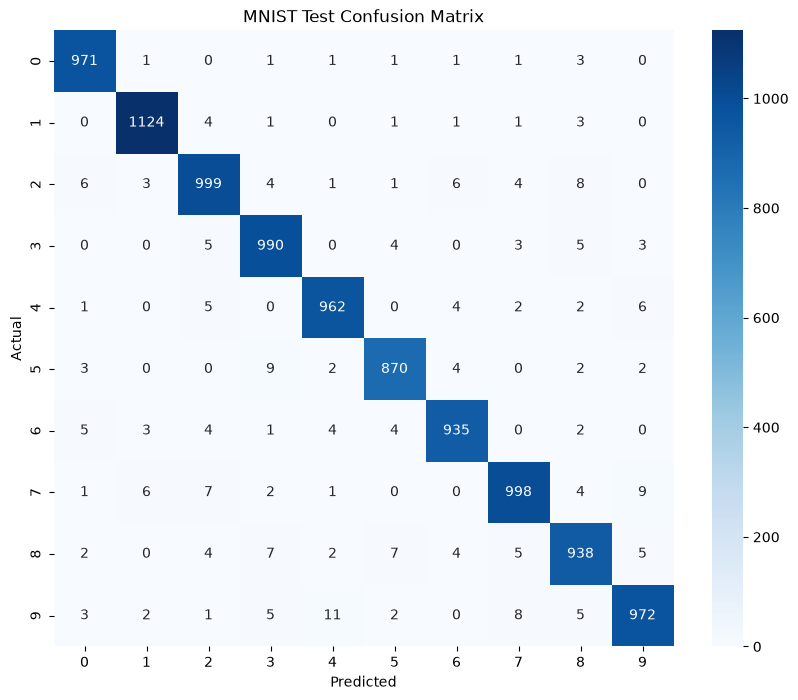

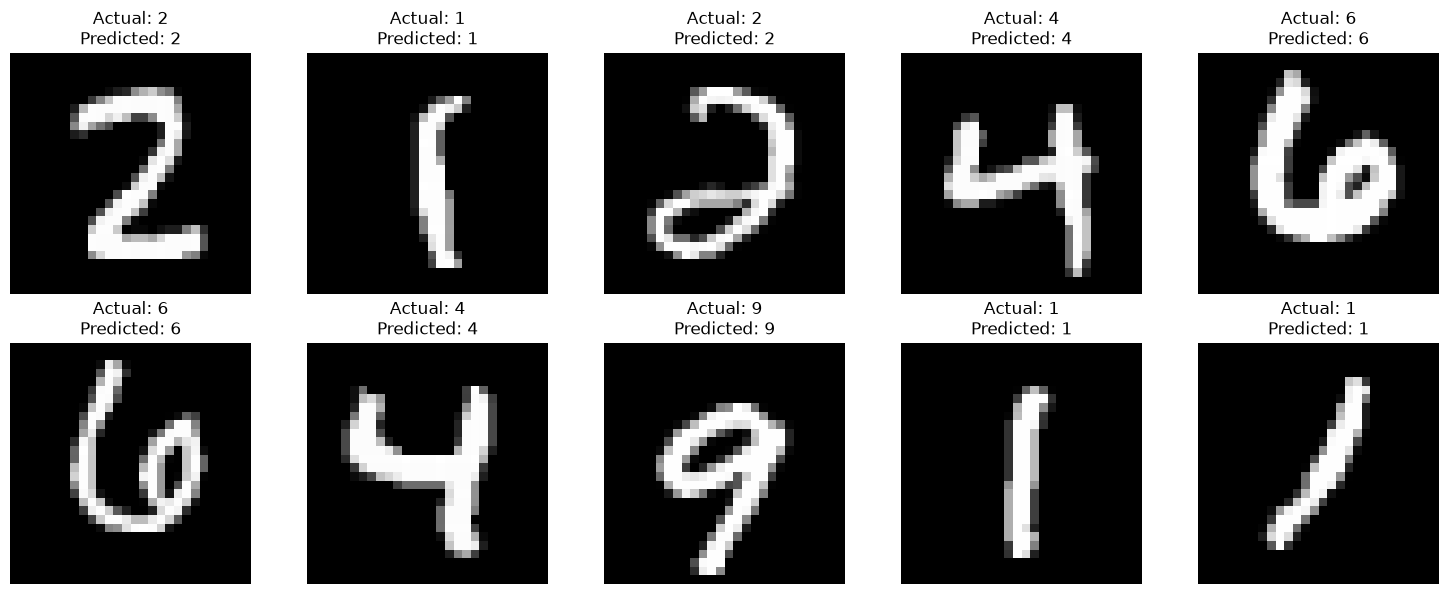


CSV saved successfully:
mnist_test_results.csv


In [7]:
import pandas as pd
import numpy as np
import random
import joblib
import csv

import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import seaborn as sns


# ==========================================
# 1 - مسار Test Dataset
# ==========================================

test_path = r"C:\Users\PC-LAB1\Desktop\New folder\day 5\mnist\archive\mnist_test.csv"


# ==========================================
# 2 - تحميل Model و Scaler
# ==========================================

model = joblib.load("mnist_ann_model.pkl")

scaler = joblib.load("mnist_scaler.pkl")


print("Model loaded successfully")

print("Scaler loaded successfully")


# ==========================================
# 3 - قراءة Test Dataset
# ==========================================

df_test = pd.read_csv(test_path)


print("\nTest Dataset loaded successfully")

print("Test shape:", df_test.shape)


# ==========================================
# 4 - فصل Label عن Features
# ==========================================

y_test = df_test["label"]

X_test = df_test.drop("label", axis=1)


# تحويل إلى NumPy

X_test = X_test.values

y_test = y_test.values


# ==========================================
# 5 - تحويل Pixel Values إلى 0-1
# ==========================================

X_test = X_test / 255.0


# ==========================================
# 6 - Scaling
# ==========================================

X_test_scaled = scaler.transform(X_test)


print("Scaling completed")


# ==========================================
# 7 - Prediction
# ==========================================

y_pred = model.predict(
    X_test_scaled
)


# ==========================================
# 8 - Accuracy
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)


print("\n======================================")

print("MNIST TEST RESULTS")

print("======================================")


print(
    f"Test Accuracy: {accuracy * 100:.2f}%"
)


# ==========================================
# 9 - Classification Report
# ==========================================

print("\n======================================")

print("Classification Report")

print("======================================")


print(
    classification_report(
        y_test,
        y_pred
    )
)


# ==========================================
# 10 - Confusion Matrix
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(10, 8))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)


plt.title("MNIST Test Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()


# ==========================================
# 11 - عرض 10 صور عشوائية
# ==========================================

random.seed(42)


random_indices = random.sample(
    range(len(X_test)),
    10
)


plt.figure(figsize=(15, 6))


for i, index in enumerate(random_indices):

    image = X_test[index].reshape(
        28,
        28
    )

    actual = y_test[index]

    prediction = y_pred[index]


    plt.subplot(
        2,
        5,
        i + 1
    )


    plt.imshow(
        image,
        cmap="gray"
    )


    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {prediction}"
    )


    plt.axis("off")


plt.tight_layout()

plt.show()


# ==========================================
# 12 - حفظ نتائج Test في CSV
# ==========================================

csv_path = "mnist_test_results.csv"


with open(
    csv_path,
    "w",
    newline="",
    encoding="utf-8"
) as file:

    writer = csv.writer(file)


    writer.writerow([
        "Actual",
        "Predicted"
    ])


    for actual, prediction in zip(
        y_test,
        y_pred
    ):

        writer.writerow([
            actual,
            prediction
        ])


print("\n======================================")

print("CSV saved successfully:")

print(csv_path)

print("======================================")

Loading Training Dataset...
Training Dataset loaded successfully
Train shape: (60000, 785)
Original Training Features: (60000, 784)
Normalization completed

Applying StandardScaler...
Scaling completed
Scaled shape: (60000, 784)

Applying PCA...
PCA completed
Original Features: 784
PCA Features: 331
Explained Variance: 95.03%

Splitting Dataset...
Training samples: 48000
Validation samples: 12000

Creating ANN Model...

START ANN TRAINING
Iteration 1, loss = 0.46935555
Iteration 2, loss = 0.16816040
Iteration 3, loss = 0.11497636
Iteration 4, loss = 0.08500776
Iteration 5, loss = 0.06853315
Iteration 6, loss = 0.05459027
Iteration 7, loss = 0.03900643
Iteration 8, loss = 0.03078497
Iteration 9, loss = 0.02880157
Iteration 10, loss = 0.02346274
Iteration 11, loss = 0.02267517
Iteration 12, loss = 0.02270377
Iteration 13, loss = 0.02387402
Iteration 14, loss = 0.01760871
Iteration 15, loss = 0.01502130
Iteration 16, loss = 0.01479369
Iteration 17, loss = 0.01374447
Iteration 18, loss = 0

C:\Users\PC-LAB1\AppData\Roaming\Python\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


Test Dataset loaded successfully
Test shape: (10000, 785)
Original Test Features: (10000, 784)
Test Scaling completed
Test PCA completed
Test PCA shape: (10000, 331)

START TESTING

MNIST TEST RESULTS
Test Accuracy: 97.15%

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.97      0.96      0.97      1032
           3       0.96      0.98      0.97      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.97      0.97       958
           7       0.97      0.97      0.97      1028
           8       0.96      0.97      0.96       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10

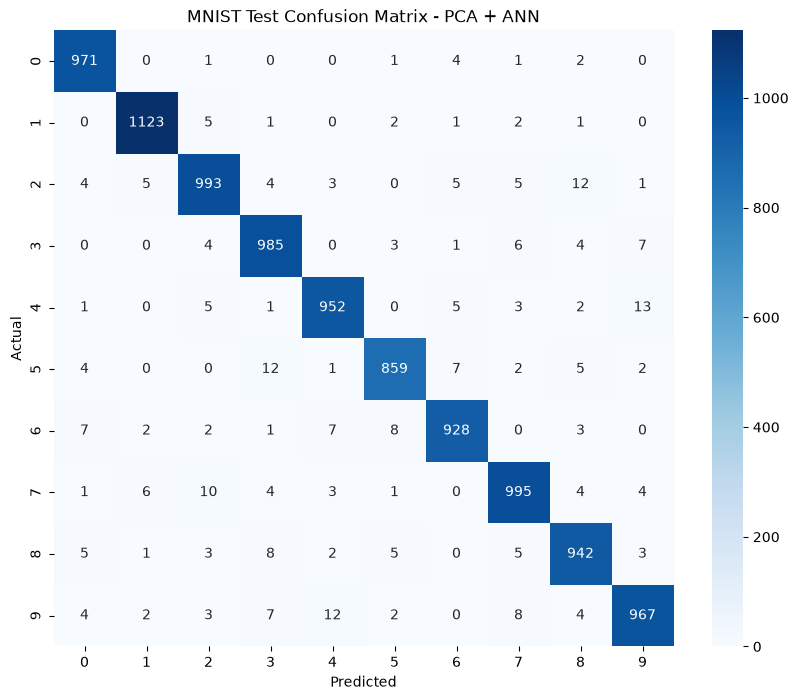


Displaying 10 random test images...


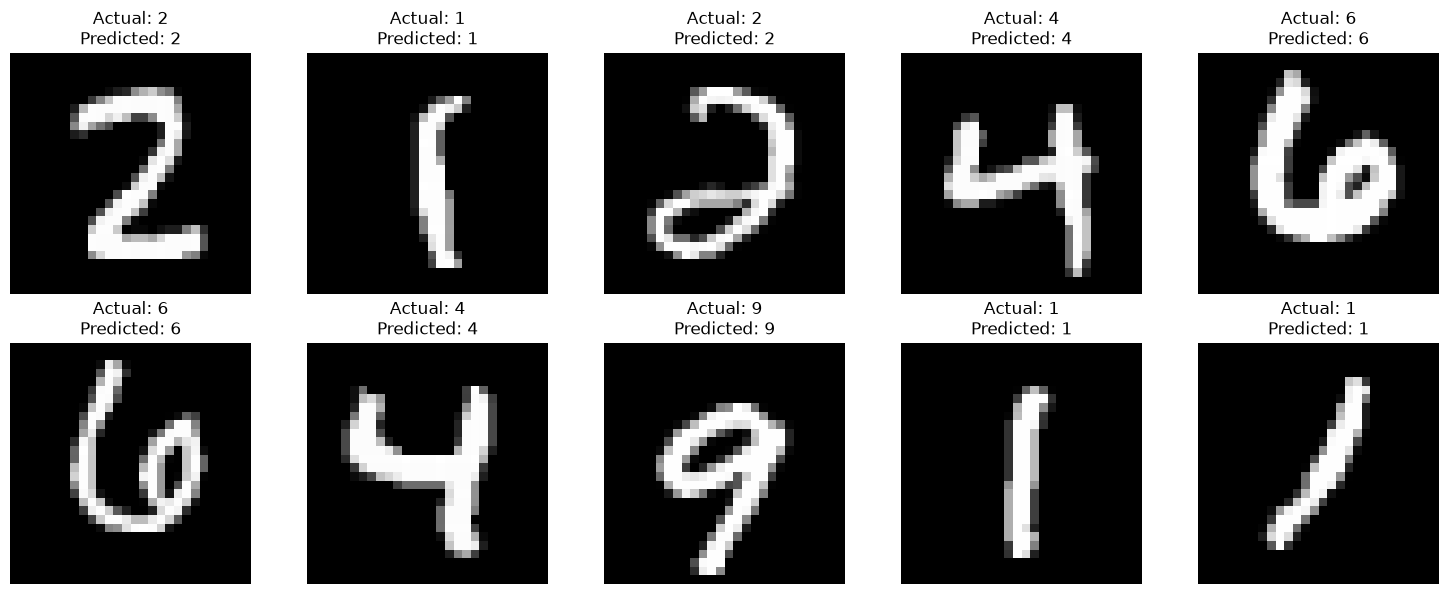


ANN Model saved successfully:
mnist_ann_pca_model.pkl
Scaler saved successfully:
mnist_scaler_pca.pkl
PCA saved successfully:
mnist_pca.pkl

CSV saved successfully:
mnist_test_results_pca.csv

FINAL RESULTS
Validation Accuracy: 97.11%
Test Accuracy: 97.15%
PCA Components: 331
Explained Variance: 95.03%


In [13]:

import pandas as pd
import numpy as np
import random
import joblib
import csv
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns


# =========================================================
# 1 - مسارات Dataset
# =========================================================

train_path = r"C:\Users\PC-LAB1\Desktop\New folder\day 5\mnist\archive\mnist_train.csv"

test_path = r"C:\Users\PC-LAB1\Desktop\New folder\day 5\mnist\archive\mnist_test.csv"


# =========================================================
# 2 - قراءة Training Dataset
# =========================================================

print("Loading Training Dataset...")

df_train = pd.read_csv(train_path)

print("Training Dataset loaded successfully")

print("Train shape:", df_train.shape)


# =========================================================
# 3 - فصل Label عن Features
# =========================================================

y_train = df_train["label"]

X_train = df_train.drop("label", axis=1)


X_train = X_train.values

y_train = y_train.values


print("Original Training Features:", X_train.shape)


# =========================================================
# 4 - تحويل Pixel Values إلى 0-1
# =========================================================

X_train = X_train / 255.0


print("Normalization completed")


# =========================================================
# 5 - StandardScaler
# =========================================================

print("\nApplying StandardScaler...")


scaler = StandardScaler()


X_train_scaled = scaler.fit_transform(
    X_train
)


print("Scaling completed")

print(
    "Scaled shape:",
    X_train_scaled.shape
)


# =========================================================
# 6 - PCA
# =========================================================

print("\nApplying PCA...")


pca = PCA(
    n_components=0.95,
    random_state=42
)


X_train_pca = pca.fit_transform(
    X_train_scaled
)


print("PCA completed")

print(
    "Original Features:",
    X_train_scaled.shape[1]
)

print(
    "PCA Features:",
    X_train_pca.shape[1]
)

print(
    f"Explained Variance: "
    f"{sum(pca.explained_variance_ratio_) * 100:.2f}%"
)


# =========================================================
# 7 - تقسيم Training إلى Train و Validation
# =========================================================

print("\nSplitting Dataset...")


X_train_final, X_val, y_train_final, y_val = train_test_split(

    X_train_pca,

    y_train,

    test_size=0.2,

    random_state=42,

    stratify=y_train
)


print("Training samples:", X_train_final.shape[0])

print("Validation samples:", X_val.shape[0])


# =========================================================
# 8 - إنشاء ANN Model
# =========================================================

print("\nCreating ANN Model...")


model = MLPClassifier(

    hidden_layer_sizes=(128, 64),

    activation="relu",

    solver="adam",

    max_iter=30,

    batch_size=128,

    random_state=42,

    verbose=True
)


# =========================================================
# 9 - Training
# =========================================================

print("\n======================================")

print("START ANN TRAINING")

print("======================================")


model.fit(

    X_train_final,

    y_train_final
)


print("\nTraining completed successfully")


# =========================================================
# 10 - Validation Prediction
# =========================================================

y_val_pred = model.predict(
    X_val
)


val_accuracy = accuracy_score(

    y_val,

    y_val_pred
)


print("\n======================================")

print("VALIDATION RESULTS")

print("======================================")


print(
    f"Validation Accuracy: "
    f"{val_accuracy * 100:.2f}%"
)


# =========================================================
# 11 - تحميل Test Dataset
# =========================================================

print("\n======================================")

print("Loading Test Dataset")

print("======================================")


df_test = pd.read_csv(
    test_path
)


print(
    "Test Dataset loaded successfully"
)

print(
    "Test shape:",
    df_test.shape
)


# =========================================================
# 12 - فصل Test Label عن Features
# =========================================================

y_test = df_test["label"]

X_test = df_test.drop(
    "label",
    axis=1
)


X_test = X_test.values

y_test = y_test.values


print(
    "Original Test Features:",
    X_test.shape
)


# =========================================================
# 13 - Normalize Test
# =========================================================

X_test = X_test / 255.0


# =========================================================
# 14 - استخدام نفس Scaler
# =========================================================

X_test_scaled = scaler.transform(
    X_test
)


print("Test Scaling completed")


# =========================================================
# 15 - استخدام نفس PCA
# =========================================================

X_test_pca = pca.transform(
    X_test_scaled
)


print("Test PCA completed")


print(
    "Test PCA shape:",
    X_test_pca.shape
)


# =========================================================
# 16 - Test Prediction
# =========================================================

print("\n======================================")

print("START TESTING")

print("======================================")


y_pred = model.predict(
    X_test_pca
)


# =========================================================
# 17 - Test Accuracy
# =========================================================

accuracy = accuracy_score(

    y_test,

    y_pred
)


print("\n======================================")

print("MNIST TEST RESULTS")

print("======================================")


print(
    f"Test Accuracy: "
    f"{accuracy * 100:.2f}%"
)


# =========================================================
# 18 - Classification Report
# =========================================================

print("\n======================================")

print("Classification Report")

print("======================================")


print(

    classification_report(

        y_test,

        y_pred

    )

)


# =========================================================
# 19 - Confusion Matrix
# =========================================================

cm = confusion_matrix(

    y_test,

    y_pred

)


plt.figure(

    figsize=(10, 8)

)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)


plt.title(
    "MNIST Test Confusion Matrix - PCA + ANN"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()


# =========================================================
# 20 - عرض 10 صور عشوائية
# =========================================================

print("\nDisplaying 10 random test images...")


random.seed(42)


random_indices = random.sample(

    range(len(X_test)),

    10

)


plt.figure(

    figsize=(15, 6)

)


for i, index in enumerate(
    random_indices
):

    # الصورة الأصلية 28x28
    image = X_test[index].reshape(
        28,
        28
    )


    actual = y_test[index]


    prediction = y_pred[index]


    plt.subplot(

        2,

        5,

        i + 1

    )


    plt.imshow(

        image,

        cmap="gray"

    )


    plt.title(

        f"Actual: {actual}\n"
        f"Predicted: {prediction}"

    )


    plt.axis("off")


plt.tight_layout()

plt.show()


# =========================================================
# 21 - حفظ Model
# =========================================================

joblib.dump(

    model,

    "mnist_ann_pca_model.pkl"

)


print(
    "\nANN Model saved successfully:"
)

print(
    "mnist_ann_pca_model.pkl"
)


# =========================================================
# 22 - حفظ Scaler
# =========================================================

joblib.dump(

    scaler,

    "mnist_scaler_pca.pkl"

)


print(
    "Scaler saved successfully:"
)

print(
    "mnist_scaler_pca.pkl"
)


# =========================================================
# 23 - حفظ PCA
# =========================================================

joblib.dump(

    pca,

    "mnist_pca.pkl"

)


print(
    "PCA saved successfully:"
)

print(
    "mnist_pca.pkl"
)


# =========================================================
# 24 - حفظ Test Results في CSV
# =========================================================

csv_path = "mnist_test_results_pca.csv"


with open(

    csv_path,

    "w",

    newline="",

    encoding="utf-8"

) as file:

    writer = csv.writer(file)


    writer.writerow([

        "Actual",

        "Predicted"

    ])


    for actual, prediction in zip(

        y_test,

        y_pred

    ):

        writer.writerow([

            actual,

            prediction

        ])


print("\n======================================")

print("CSV saved successfully:")

print(csv_path)

print("======================================")


# =========================================================
# 25 - Final Results
# =========================================================

print("\n======================================")

print("FINAL RESULTS")

print("======================================")


print(

    f"Validation Accuracy: "
    f"{val_accuracy * 100:.2f}%"

)


print(

    f"Test Accuracy: "
    f"{accuracy * 100:.2f}%"

)


print(

    f"PCA Components: "
    f"{X_train_pca.shape[1]}"

)


print(

    f"Explained Variance: "
    f"{sum(pca.explained_variance_ratio_) * 100:.2f}%"

)


print("======================================")



Model loaded successfully
Scaler loaded successfully
PCA loaded successfully
Original image size: (405, 350)
Image shape before Scaling: (1, 784)
Image shape after PCA: (1, 331)

MNIST IMAGE TEST
Predicted Digit: 2
Confidence: 100.00%


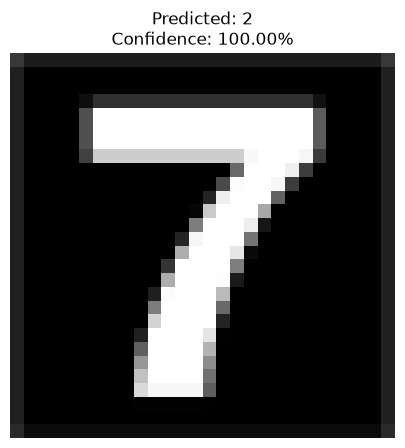

In [19]:

import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt


# ==========================================
# 1 - مسار الصورة
# ==========================================

image_path = r"C:\Users\PC-LAB1\Desktop\New folder\day 5\dc7_hi_3.gif"


# ==========================================
# 2 - تحميل Model و Scaler و PCA
# ==========================================

model = joblib.load("mnist_ann_pca_model.pkl")

scaler = joblib.load("mnist_scaler_pca.pkl")

pca = joblib.load("mnist_pca.pkl")


print("Model loaded successfully")
print("Scaler loaded successfully")
print("PCA loaded successfully")


# ==========================================
# 3 - قراءة الصورة
# ==========================================

image = cv2.imread(
    image_path,
    cv2.IMREAD_GRAYSCALE
)


if image is None:

    print("Error: Image not found")

    exit()


print("Original image size:", image.shape)


# ==========================================
# 4 - Resize إلى 28x28
# ==========================================

image_28 = cv2.resize(

    image,

    (28, 28),

    interpolation=cv2.INTER_AREA

)


# ==========================================
# 5 - التأكد من اتجاه الألوان
# ==========================================

# MNIST:
# Background = Black
# Digit = White

if np.mean(image_28) > 127:

    image_28 = 255 - image_28


# ==========================================
# 6 - تحويل Pixel Values إلى 0-1
# ==========================================

image_normalized = image_28 / 255.0


# ==========================================
# 7 - تحويل الصورة إلى Vector
# ==========================================

image_flatten = image_normalized.reshape(
    1,
    784
)


print(
    "Image shape before Scaling:",
    image_flatten.shape
)


# ==========================================
# 8 - Scaling
# ==========================================

image_scaled = scaler.transform(

    image_flatten

)


# ==========================================
# 9 - PCA
# ==========================================

image_pca = pca.transform(

    image_scaled

)


print(
    "Image shape after PCA:",
    image_pca.shape
)


# ==========================================
# 10 - Prediction
# ==========================================

prediction = model.predict(

    image_pca

)


predicted_digit = prediction[0]


# ==========================================
# 11 - Probability
# ==========================================

probabilities = model.predict_proba(

    image_pca

)


confidence = np.max(
    probabilities
) * 100


# ==========================================
# 12 - عرض النتيجة
# ==========================================

print("\n======================================")

print("MNIST IMAGE TEST")

print("======================================")


print(
    "Predicted Digit:",
    predicted_digit
)


print(
    f"Confidence: {confidence:.2f}%"
)


print("======================================")


# ==========================================
# 13 - عرض الصورة
# ==========================================

plt.figure(

    figsize=(5, 5)

)


plt.imshow(

    image_28,

    cmap="gray"

)


plt.title(

    f"Predicted: {predicted_digit}\n"
    f"Confidence: {confidence:.2f}%"

)


plt.axis("off")


plt.show()



Model loaded successfully
Scaler loaded successfully
Original image size: (405, 350)
HOG Features: 1296
Hu Moments: 7
Total Features: 1303
Scaling completed

MNIST IMAGE TEST
HOG + HU + ANN
Predicted Digit: 7
Confidence: 99.99%


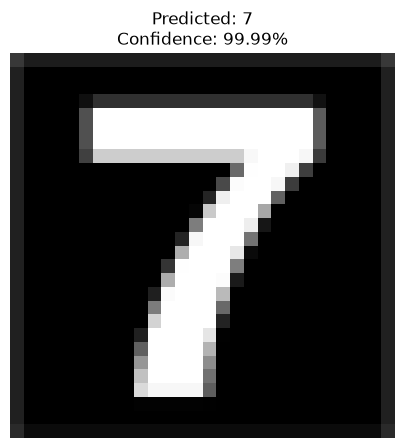

In [20]:

import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt

from skimage.feature import hog


# ==========================================
# 1 - مسار الصورة
# ==========================================

image_path = r"C:\Users\PC-LAB1\Desktop\New folder\day 5\dc7_hi_3.gif"


# ==========================================
# 2 - تحميل Model و Scaler
# ==========================================

model = joblib.load(
    "mnist_hog_hu_ann_model.pkl"
)

scaler = joblib.load(
    "mnist_hog_hu_scaler.pkl"
)


print("Model loaded successfully")
print("Scaler loaded successfully")


# ==========================================
# 3 - قراءة الصورة
# ==========================================

image = cv2.imread(

    image_path,

    cv2.IMREAD_GRAYSCALE

)


if image is None:

    print("Error: Image not found")

    exit()


print(
    "Original image size:",
    image.shape
)


# ==========================================
# 4 - Resize إلى 28x28
# ==========================================

image_28 = cv2.resize(

    image,

    (28, 28),

    interpolation=cv2.INTER_AREA

)


# ==========================================
# 5 - التأكد من اتجاه الألوان
# ==========================================

# MNIST:
# Background = Black
# Digit = White

if np.mean(image_28) > 127:

    image_28 = 255 - image_28


# ==========================================
# 6 - تحويل Pixel Values إلى 0-1
# ==========================================

image_normalized = image_28 / 255.0


# ==========================================
# 7 - HOG Features
# ==========================================

hog_features = hog(

    image_normalized,

    orientations=9,

    pixels_per_cell=(4, 4),

    cells_per_block=(2, 2),

    block_norm="L2-Hys"

)


print(
    "HOG Features:",
    len(hog_features)
)


# ==========================================
# 8 - Hu Moments
# ==========================================

# تحويل الصورة إلى 0-255

image_uint8 = (

    image_normalized * 255

).astype(np.uint8)


# حساب Moments

moments = cv2.moments(

    image_uint8

)


# حساب Hu Moments

hu_moments = cv2.HuMoments(

    moments

).flatten()


# ==========================================
# 9 - Log Transform لـ Hu Moments
# ==========================================

for i in range(

    len(hu_moments)

):

    if hu_moments[i] != 0:

        hu_moments[i] = (

            -np.sign(
                hu_moments[i]
            )

            *

            np.log10(
                abs(
                    hu_moments[i]
                )
            )

        )


print(
    "Hu Moments:",
    len(hu_moments)
)


# ==========================================
# 10 - دمج HOG + Hu
# ==========================================

combined_features = np.concatenate(

    [

        hog_features,

        hu_moments

    ]

)


print(
    "Total Features:",
    len(combined_features)
)


# ==========================================
# 11 - تحويل إلى 2D
# ==========================================

combined_features = combined_features.reshape(

    1,

    -1

)


# ==========================================
# 12 - Scaling
# ==========================================

image_scaled = scaler.transform(

    combined_features

)


print(
    "Scaling completed"
)


# ==========================================
# 13 - Prediction
# ==========================================

prediction = model.predict(

    image_scaled

)


predicted_digit = prediction[0]


# ==========================================
# 14 - Probability
# ==========================================

probabilities = model.predict_proba(

    image_scaled

)


confidence = np.max(

    probabilities

) * 100


# ==========================================
# 15 - عرض النتيجة
# ==========================================

print("\n======================================")

print("MNIST IMAGE TEST")

print("HOG + HU + ANN")

print("======================================")


print(

    "Predicted Digit:",

    predicted_digit

)


print(

    f"Confidence: {confidence:.2f}%"

)


print("======================================")


# ==========================================
# 16 - عرض الصورة
# ==========================================

plt.figure(

    figsize=(5, 5)

)


plt.imshow(

    image_28,

    cmap="gray"

)


plt.title(

    f"Predicted: {predicted_digit}\n"

    f"Confidence: {confidence:.2f}%"

)


plt.axis("off")


plt.show()

